# Unemployment Analysis in India

## Objective

The objective of this project is to perform exploratory data analysis on
unemployment data in India and identify regional and temporal trends,
including changes in unemployment rates during the COVID-19 pandemic.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Check the number of rows and columns

print("Shape of dataset:", df.shape)

Shape of dataset: (768, 7)


In [4]:
# Display column names

print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [5]:
# Check data types

df.dtypes

Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

In [6]:
# Check for missing values

df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
# Calculate percentage of missing values

(df.isnull().sum() / len(df)) * 100

Region                                      3.645833
 Date                                       3.645833
 Frequency                                  3.645833
 Estimated Unemployment Rate (%)            3.645833
 Estimated Employed                         3.645833
 Estimated Labour Participation Rate (%)    3.645833
Area                                        3.645833
dtype: float64

In [8]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [9]:
# Remove extra spaces from text columns

df['Region'] = df['Region'].str.strip()

In [10]:
df['Area'] = df['Area'].str.strip()

In [11]:
# Convert Date column to datetime

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Date'].head()

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]

In [12]:
df.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

In [13]:
# Check the earliest and latest dates

print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00


In [14]:
# Descriptive statistics

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [15]:
# Display unique regions

print(df['Region'].unique())

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str


In [16]:
# Count records for each region

df['Region'].value_counts()

Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Karnataka           28
Kerala              28
Madhya Pradesh      28
Maharashtra         28
Odisha              28
Punjab              28
Rajasthan           28
Tamil Nadu          28
Telangana           28
Tripura             28
Uttar Pradesh       28
West Bengal         28
Meghalaya           27
Uttarakhand         27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64

In [19]:
# Extract year and month from Date

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df[['Date', 'Year', 'Month']].head()



,Date,Year,Month
0,2019-05-31,2019.0,5.0
1,2019-06-30,2019.0,6.0
2,2019-07-31,2019.0,7.0
3,2019-08-31,2019.0,8.0
4,2019-09-30,2019.0,9.0


In [20]:
df['Month_Name'] = df['Date'].dt.strftime('%B')

df[['Date', 'Month', 'Month_Name']].head()

,Date,Month,Month_Name
0,2019-05-31,5.0,May
1,2019-06-30,6.0,June
2,2019-07-31,7.0,July
3,2019-08-31,8.0,August
4,2019-09-30,9.0,September


In [21]:
# Calculate average unemployment rate for each region

region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_avg = region_avg.sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

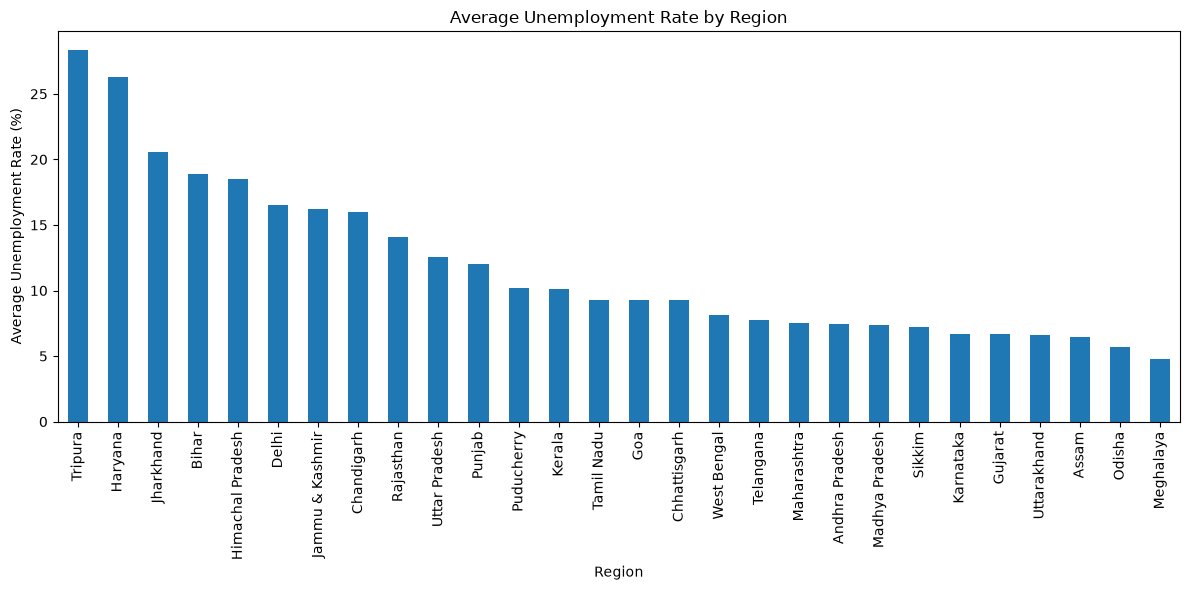

In [22]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Observation

The average unemployment rate varies considerably across regions.
Some regions have consistently higher unemployment rates than others,
indicating differences in employment conditions across India.

In [ ]:
# Calculate average unemployment rate by month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg

Month
1.0      9.950755
2.0      9.964717
3.0     10.700577
4.0     23.641569
5.0     16.646190
6.0     10.553462
7.0      9.033889
8.0      9.637925
9.0      9.051731
10.0     9.900909
11.0     9.868364
12.0     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

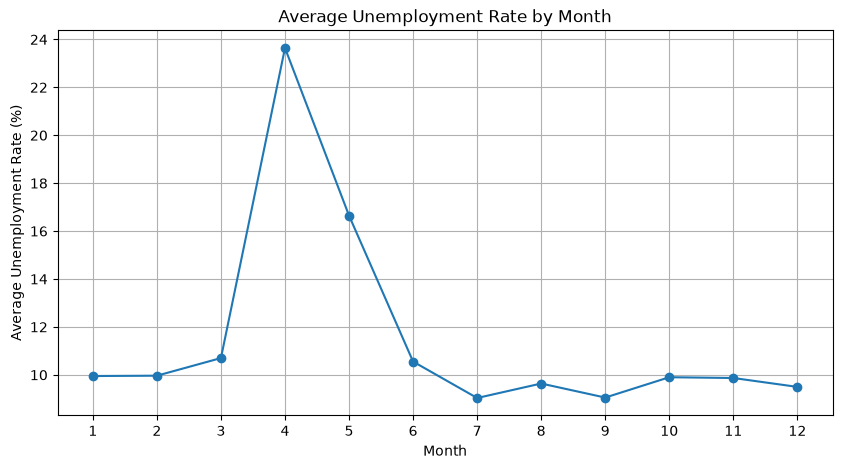

In [24]:
# month wise trend 

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()

### Observation

The month-wise analysis shows that the average unemployment rate varies
across different months. Since the values represent averages across the
available years, the pattern provides an overall view of monthly variation
but does not by itself establish a strong seasonal effect.

Time Series Analysis

In [27]:
selected_regions = [
    'Andhra Pradesh',
    'Tamil Nadu',
    'Karnataka'
]

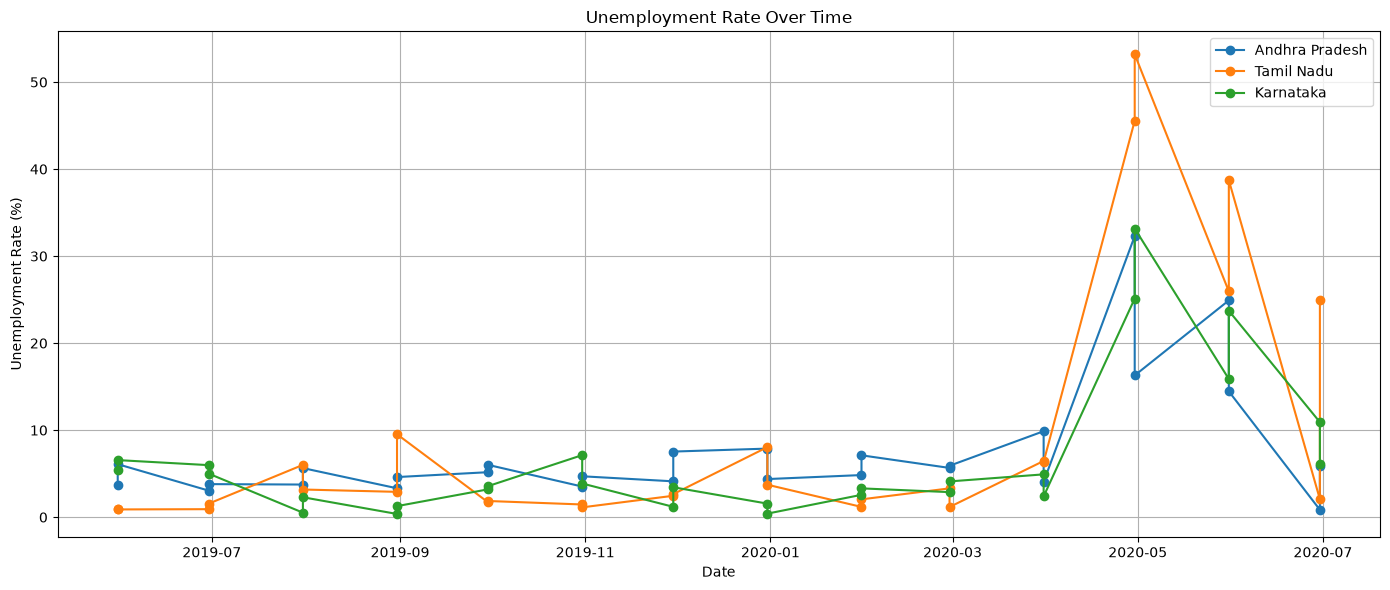

In [ ]:
plt.figure(figsize=(14, 6))

for region in selected_regions:
    
    region_data = df[df['Region'] == region].sort_values('Date')
    
    plt.plot(
        region_data['Date'],
        region_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=region
    )

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The time-series plot shows how unemployment rates changed over time in
the selected regions. The regions display different patterns and levels
of unemployment. A noticeable increase can be observed around the period
of the COVID-19 pandemic, particularly during 2020.

In [29]:
# Calculate average unemployment rate by region

top_regions = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

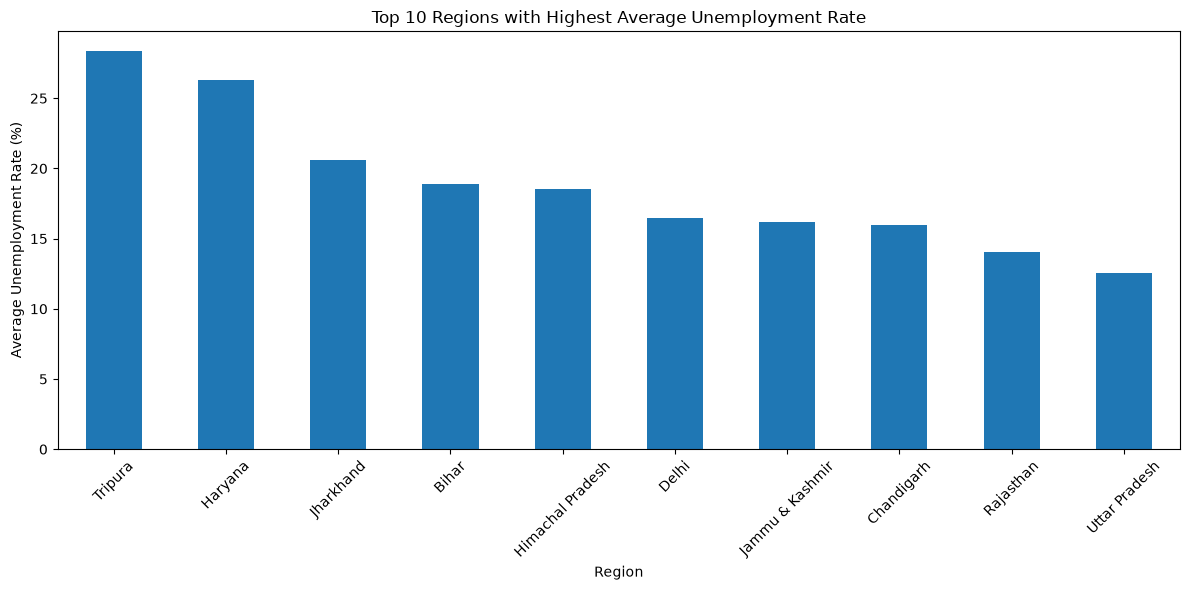

In [30]:
plt.figure(figsize=(12, 6))

top_regions.plot(kind='bar')

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows the ten regions with the highest average unemployment
rates during the period covered by the dataset. The results indicate that
unemployment was not evenly distributed across India, with some regions
experiencing substantially higher average unemployment rates.

## Correlation analysis

In [31]:
# Select numerical columns

correlation_data = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

# Calculate correlation

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


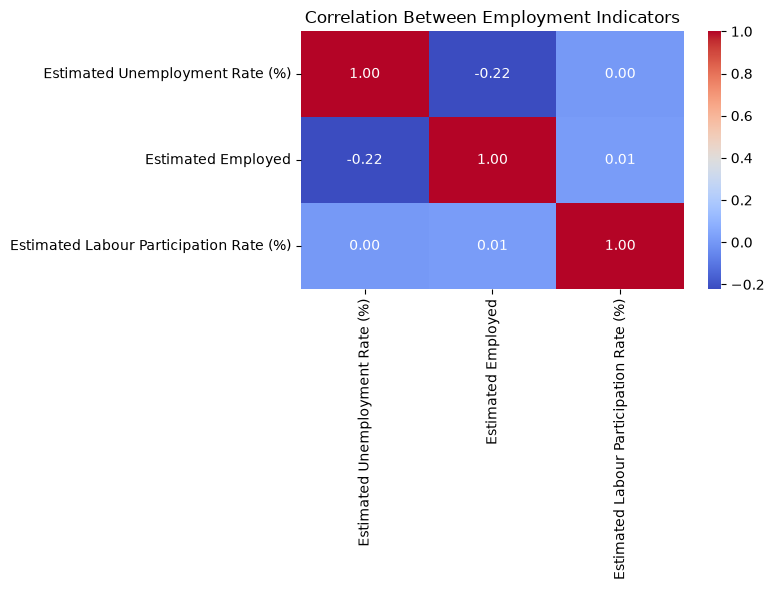

In [32]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength and direction of the relationships
between unemployment, employment, and labour participation.

A negative correlation indicates that two variables tend to move in opposite
directions, while a positive correlation indicates that they tend to increase
or decrease together.

Correlation does not necessarily imply a causal relationship.

## Create Pre-COVID and Post-COVID datasets

In [33]:
# Define COVID period

covid_date = pd.Timestamp('2020-03-01')

# Pre-COVID data

pre_covid = df[df['Date'] < covid_date]

# Post-COVID data

post_covid = df[df['Date'] >= covid_date]

print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 536
Post-COVID records: 204


In [34]:
# Calculate average unemployment rate

pre_covid_unemployment = pre_covid[
    'Estimated Unemployment Rate (%)'
].mean()

post_covid_unemployment = post_covid[
    'Estimated Unemployment Rate (%)'
].mean()

print("Pre-COVID average unemployment rate:",
      pre_covid_unemployment)

print("Post-COVID average unemployment rate:",
      post_covid_unemployment)

Pre-COVID average unemployment rate: 9.509533582089553
Post-COVID average unemployment rate: 17.774362745098042


In [40]:
# Calculate average employment indicators for each period

pre_covid_avg = pre_covid[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].mean()

post_covid_avg = post_covid[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].mean()

print("Pre-COVID averages:")
print(pre_covid_avg)

print("\nPost-COVID averages:")
print(post_covid_avg)

Pre-COVID averages:
Estimated Unemployment Rate (%)            9.509534e+00
Estimated Employed                         7.466028e+06
Estimated Labour Participation Rate (%)    4.388612e+01
dtype: float64

Post-COVID averages:
Estimated Unemployment Rate (%)            1.777436e+01
Estimated Employed                         6.517203e+06
Estimated Labour Participation Rate (%)    3.933005e+01
dtype: float64


In [41]:
covid_comparison = pd.DataFrame({
    'Pre-COVID': pre_covid_avg,
    'Post-COVID': post_covid_avg
})

covid_comparison

,Pre-COVID,Post-COVID
Estimated Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Estimated Labour Participation Rate (%),4.388612e+01,3.933005e+01


## Visualize Covid Comparision

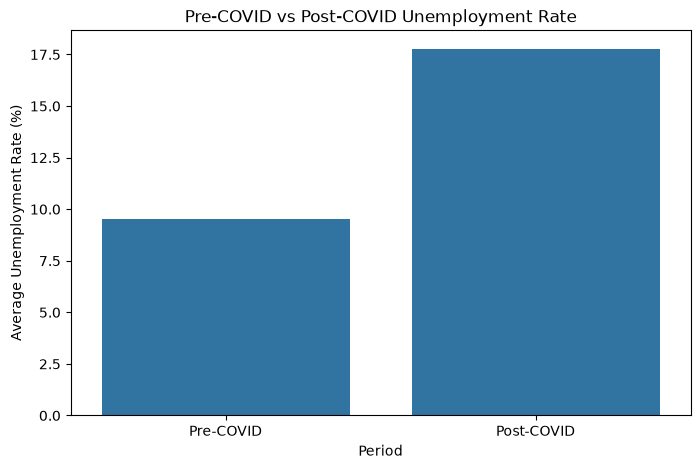

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Average Unemployment Rate'
)

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

In [37]:
change = post_covid_unemployment - pre_covid_unemployment

print("Change in average unemployment rate:", change)

Change in average unemployment rate: 8.26482916300849


In [38]:
percentage_change = (
    (post_covid_unemployment - pre_covid_unemployment)
    / pre_covid_unemployment
) * 100

print("Percentage change:", percentage_change)

Percentage change: 86.91098350580133


In [42]:
print("Pre-COVID:", round(pre_covid_unemployment, 2))
print("Post-COVID:", round(post_covid_unemployment, 2))
print("Change:", round(change, 2))
print("Percentage change:", round(percentage_change, 2), "%")

Pre-COVID: 9.51
Post-COVID: 17.77
Change: 8.26
Percentage change: 86.91 %


### COVID-19 Impact Observation

The analysis shows a significant increase in India's average unemployment
rate during the post-COVID period.

The average unemployment rate increased from **9.51% before COVID-19 to
17.77% after March 2020**, representing an increase of **8.26 percentage
points** or approximately **86.91%**.

This indicates that the period following the onset of the COVID-19 pandemic
was associated with a substantial deterioration in employment conditions in
India.

However, this analysis identifies an association between the COVID-19 period
and unemployment and does not establish that COVID-19 alone caused the
increase.

# Conclusion

This project analyzed unemployment trends in India using Python, Pandas,
Matplotlib, and Seaborn.

The exploratory analysis examined regional differences, month-wise trends,
unemployment rates over time, the regions with the highest average
unemployment rates, and correlations between key employment indicators.

The time-series analysis showed that unemployment rates varied across
regions and changed considerably over time. The COVID-19 analysis showed
a substantial increase in the average unemployment rate, from **9.51% in
the pre-COVID period to 17.77% in the post-COVID period**. This represents
an increase of **8.26 percentage points**, or approximately **86.91%**.

Overall, the analysis demonstrates how exploratory data analysis and
visualization can be used to identify regional and temporal patterns in
unemployment and examine changes associated with major economic events.